# Deep Dive

## Part 1: Introduction & Pilot Data

Let's consider data collected from **two groups**:
- Group A
- Group B

We collect pilot data from **N=5** subjects in the two groups.

In [1]:
# Load in the necessary libraries
from scipy.io import loadmat
import scipy.stats as stats
from scipy.stats import t, nct, ttest_ind
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load in the data.
data = loadmat("pilot_two_group_data.mat")
Group_A = data['Group_A']
Group_B = data['Group_B']

In [3]:
# Use a t-test to test the difference in mean between the two groups.
t_stat, p_value = stats.ttest_ind(Group_A, Group_B, equal_var=True)

# Also print out the mean and standard devaition for each group.
print('Group A -> Mean, STD: ', np.mean(Group_A), ',', np.std(Group_A))
print('Group B -> Mean, STD:', np.mean(Group_B), ',', np.std(Group_B))
print('Difference in Mean between Groups:', np.mean(Group_A)-np.mean(Group_B))
print('p:', p_value)

Group A -> Mean, STD:  11.720002555371144 , 13.642385484595346
Group B -> Mean, STD: -2.3950062043152864 , 9.47395131954884
Difference in Mean between Groups: 14.11500875968643
p: [0.12762116]


Pilot results show:
- Measure in Group A > Measure in Group B.
- The difference in mean between the two groups is $\approx$ 14.
- However, this difference is not significant (p=0.128, using a t-test).

**Q:** How many subjects do we need for a sufficiently powered study?

**A:** Let's consider our 3 different paths.

## Path 3A: Resample the pilot data.

With N=5 in each group from our pilot data, resampling is risky.

In doing so, we assume that the 5 subjects in each group provide a good enough represenation of the diverity of the data in the mostly unobserved populations.

Let's consider the case where collecting data is extremely time consuming and expensive, so adding to our pilot data is not practical. And let's also assume these data provide a good enough representation of the two populations.

In that case, we feel comfortable with resampling. Let's do so and compute the power for different choices of sample size.

In [4]:
N_resampled = 15                                             # Choose the sample size to investigate.
alpha       = 0.05
K           = 1000                                           # The total number of times we repeat our experiment.
p_values    = np.zeros(K)
for k in np.arange(K):                                       # For each resample,
    ind = np.random.choice(np.size(Group_A), N_resampled)    # ... get N_resampled indices from Group A,
    Group_A_resampled = Group_A[ind]                         # ... to create pseudodata for Group A.
    ind = np.random.choice(np.size(Group_B), N_resampled)    # ... get N_resampled indices from Group B,
    Group_B_resampled = Group_B[ind]                         # ... to create pseudodata for Group B.
                                                             # Perform our statistical test on the resampled data,
    _, p_value = stats.ttest_ind(Group_A_resampled, Group_B_resampled, equal_var=True)
    p_values[k] = p_value[0]                                 # ... and save the p-value.
statistical_power = np.sum(p_values < alpha)/K               # Calculate power as proportion of tests that reject the null hypothesis.
print('Statistical power = {:.3f}'.format(statistical_power), 'for N_resampled={:.0f}'.format(N_resampled), 'and alpha={:.2f}'.format(alpha))

Statistical power = 0.872 for N_resampled=15 and alpha=0.05


## Path 3B: Build a model with the pilot data.
**Model:** In this case, we are comparing two normally distributed groups. Rather than creating a model around a specific type of relationship, as we did earlier, here our model consists of these two distribitions. To specify the model, we need only determine the parameters for the normal distributions - mean and standard deviation - for each of the two groups.

In this case, we're interested in the difference in the means between the two groups; this is the effect size. Rather than specifying the mean for each group, we can get away with only specifying this difference.

Let's now use the pilot data to estimate model parameters
- standard deviation of each group (can be different), and
- the difference in mean between groups --> this is the effect size.

Draw data from the model and perform the statistical test for different N.

**Conclusion:** We need about N=12 subjects in each group.

**NOTE:** For our model, we chose two normal distributions, specified by their means and standard deviations. However, that's not the only choice. We may have reason to beleive (e.g., our pilot data or knowledge of the system) that the data follow another distribution (e.g., a Poisson distribution or a gamma distribution). In that case, we would need to specify different parameters (e.g, the expected rate for a Poisson distribution or the shape and rate parameters for a gamma distribition). We would also need to rethink our statistical test; the t-test is appropriate for normally distributed data. Modeling always requires making explicit choices about your system.

In [5]:
# Estimate model parameters (SD, mean difference) from the pilot data.
Group_A_SD = np.std(Group_A);
Group_B_SD = np.std(Group_B);
d          = np.mean(Group_A) - np.mean(Group_B);

# Generate randomized data and test repeatedly
alpha       = 0.05
n_list = np.arange(4,30,2)                              # List of sample sizes to evaluate (from 4 to 30 in steps of 2)
statistical_power  = np.zeros(np.shape(n_list))
for i, N in enumerate(n_list):                          # For each sample size,
    K = 2000;                                           # ... repeat K experiments,
    p_values = np.zeros(K)
    for k in np.arange(K):                              # For each experiment
        gB = np.random.randn(N,1) * Group_B_SD          # ... get N samples from Group B,
        gA = np.random.randn(N,1) * Group_A_SD + d      # ... get N samples from Group A,
                                                        # Perform our statistical test on the resampled data,
        _, p_value = stats.ttest_ind(gB, gA, equal_var=False)
        p_values[k] = p_value[0]                        # ... and save the p-value.
    statistical_power[i] = np.sum(p_values < alpha)/K   # Calculate power as percent of tests that reject the null hypothesis.
    print(N,statistical_power[i])

4 0.251
6 0.4425
8 0.6155
10 0.7295
12 0.816
14 0.8425
16 0.9105
18 0.935
20 0.958
22 0.969
24 0.975
26 0.9905
28 0.991


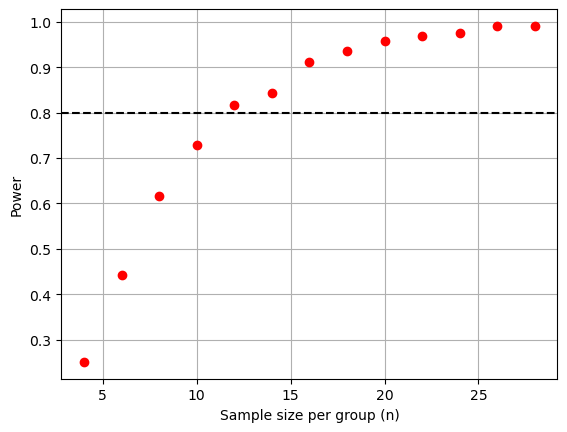

In [6]:
# Plot the results of power versus N.
plt.figure()
plt.plot(n_list, statistical_power, 'ro')
plt.grid()
plt.axhline(0.80, color='k', linestyle='--')
plt.xlabel('Sample size per group (n)')
plt.ylabel('Power');

# Path 3C: Build a model without pilot data.
Use our prior knowledge that:
- Data from both groups are drawn from normal distribitions.
- SD=10 years **is the same** for the two groups (i.e., equal variance).
- Difference in mean between the two groups is 12 -- this is our anticipated effect size.

Compare the power results from sampling the model to the **textbook power formula** from a two-sided two-sample t-test.

**Conclusion:** 
- The textbook formula and model sampling match when we use the same assumptions in our model as assumed by the textbook formula.
- We need about N=12 subjects in each group.

**NOTE:** For our model, we make many assuptions. We assume the data are normally distributed, with equal standard deviations, and with an effect size (difference in means) of 12. What if our system is more complicated (e.g., what if the variance is not equal between groups)? In that case, we may not trust the results of our power calculation and further investigation - including discussions with a friendly statistician - is advised.

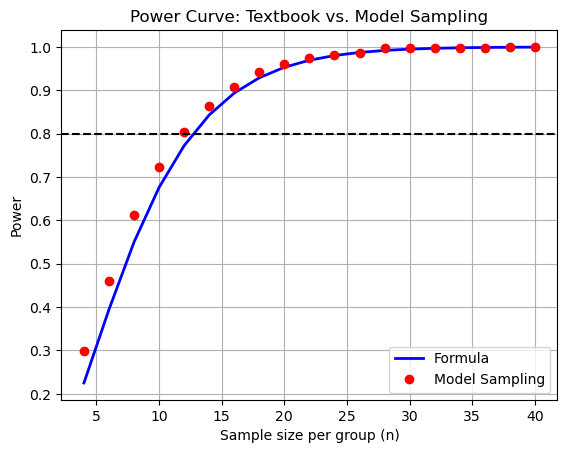

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, nct, ttest_ind

# Parameters we choose for our model
SD = 10                               # Standard deviation of each group
d  = 12                               # Difference in means between groups (effect size) 
alpha = 0.05                          # Type I error rate

# Sample sizes per group to evaluate
n_list = np.arange(4, 41, 2)

# We'll compute power using the textbook formulation and using our model.
power_textbook_curve = np.zeros(len(n_list))
power_modeling_curve = np.zeros(len(n_list))

for i, N in enumerate(n_list):
    df_k = 2 * N - 2                     # Degrees of freedom

    # Power for two-sided two-sample t-test (from the textbook)
    tstat = d / (SD * np.sqrt(2 / N))    # t-statistic, depends on difference in means (numerator), standard deviation (denominator), and sqrt(2/sample size) (denominator)
    tcrit = t.ppf(1 - alpha / 2, N)     # Two-sided critical t-value
    power_textbook_curve[i] = (1 - nct.cdf(tcrit, df_k, tstat) + nct.cdf(-tcrit, df_k, tstat))

    # Modeling estimate
    K = 2000;                                           # ... repeat K experiments,
    p_values = np.zeros(K)
    for k in np.arange(K):                              # For each experiment
        gB = np.random.randn(N,1) * SD                  # ... get N samples from Group B,
        gA = np.random.randn(N,1) * SD + d              # ... get N samples from Group A,
                                                        # Perform our statistical test on the resampled data,
        _, p_value = stats.ttest_ind(gB, gA, equal_var=True)
        p_values[k] = p_value[0]                        # ... and save the p-value.
    power_modeling_curve[i] = np.sum(p_values < alpha)/K   # Calculate power as percent of tests that reject the null hypothesis.

# Plot
plt.figure()
plt.plot(n_list, power_textbook_curve, 'b-', linewidth=2, label='Formula')
plt.plot(n_list, power_modeling_curve, 'ro', markerfacecolor='r', label='Model Sampling')
plt.axhline(0.80, color='k', linestyle='--')
plt.xlabel('Sample size per group (n)')
plt.ylabel('Power')
plt.title('Power Curve: Textbook vs. Model Sampling')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()